In [1]:
from Imports import *
from Plotting import *
from Helper import *
from Preprocessing import *

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../../QuGAN/data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.noise = GaussianNoise(sigma=0.1)

        self.feature_gen = nn.Sequential(
            nn.Linear(9, 256),
            nn.LayerNorm(256),
            self.noise
        )

        self.image_gen1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1x1 → 2x2
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 2x2 → 4x4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 4x4 → 8x8
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )

        self.image_gen4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 8x8 → 16x16
            nn.Sigmoid()
        )

    def forward(self, z_feat):
        img = self.feature_gen(z_feat)
        # print(img.shape)
        img = img.view(-1, 256, 1, 1)
        # print(img.shape)
        img = self.image_gen1(img)
        # print(img.shape)
        img = self.image_gen2(img)
        # print(img.shape)
        img = self.image_gen3(img)
        # print(img.shape)
        img = self.image_gen4(img)
        # print(img.shape)
        img = soft_threshold(img, threshold=0.001, sharpness=1000.0)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Flattened image: 16x16 = 256
        self.image_encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Flatten()
        )

        self.feature_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )

        # Dynamically get input dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16, 16)
            flat_dim = self.image_encoder(dummy).shape[1] + 64

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, img, features):
        img_encoded = self.image_encoder(img)
        feat_encoded = self.feature_encoder(features)
        combined = torch.cat((img_encoded, feat_encoded), dim=1)

        # print(img_encoded.shape)
        # print(feat_encoded.shape)
        # print(combined.shape[-1])

        prob = self.classifier(combined)

        return prob  # Shape: (batch_size, 1)

Image shape: torch.Size([872666, 16, 16])
dR Mean: torch.Size([872666])
dR STD: torch.Size([872666])
Pixel Mean: torch.Size([872666])
Pixel STD: torch.Size([872666])
ΔR min: 0.0
ΔR max: 2.4713454246520996
ΔR mean min: 0.003572926390916109
ΔR mean max: 0.015763528645038605
ΔR std min: 0.017520317807793617
ΔR std max: 0.16022197902202606
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0028264394495636225
Pixel mean max: 0.004322932101786137
Pixel std min: 0.008012386038899422
Pixel std max: 0.06249340996146202


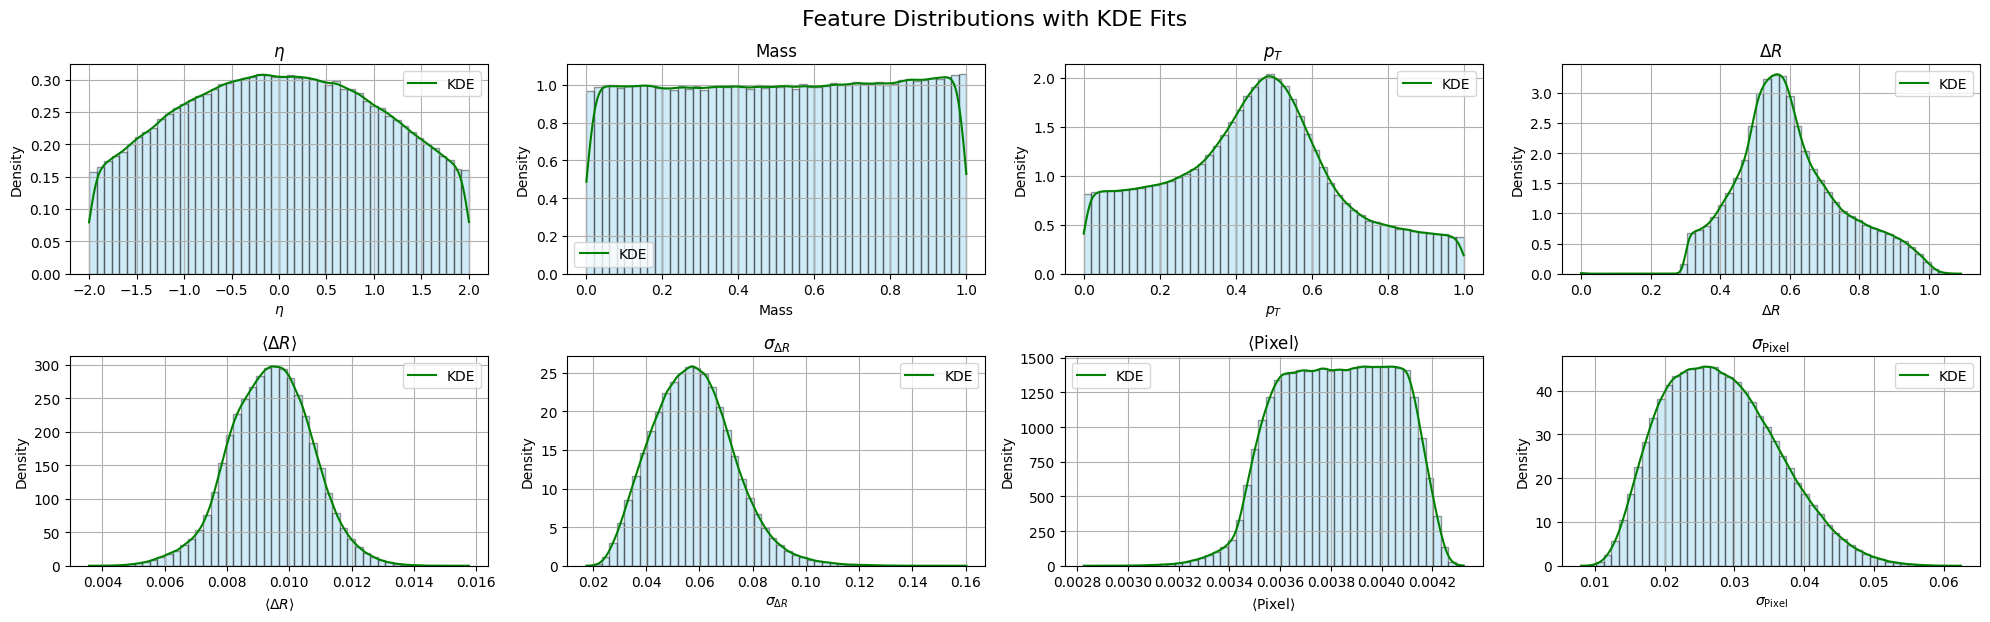

Number of samples: 872666
Image shape: torch.Size([872666, 16, 16])
Feature shape: torch.Size([872666, 9])


In [4]:
batch_size = 128
n_events = int(1 * jet_mass_data['image'].shape[0])

latent_dim = 256
lr = 1e-3
n_epochs = 100
num = 4

dataset = JetDataset(jet_mass_data, n_events)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

kdes = feature_distributions(dataset)

print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

In [5]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.9, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.9, 0.999))

scheduler_G = CosineAnnealingLR(optimizer_G, T_max=n_epochs, eta_min=1e-4)
scheduler_D = CosineAnnealingLR(optimizer_D, T_max=n_epochs, eta_min=1e-4)

g_losses = []
d_losses = []

# Tracking buffers
stats_dict = {
    'fake_dR_mean': [],
    'fake_dR_std': [],
    'fake_pixel_mean': [],
    'fake_pixel_std': [],
    'real_dR_mean': [],
    'real_dR_std': [],
    'real_pixel_mean': [],
    'real_pixel_std': []
}

dists = compute_distance_map(16,16).to(device)

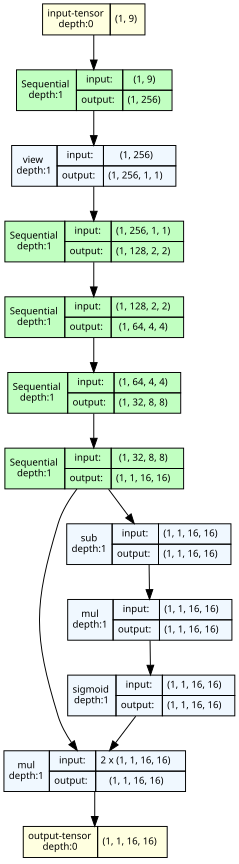

In [6]:
graph =  draw_graph(
    generator,
    input_size=(1, 9),
    expand_nested=True,
    depth = 1,
    graph_name="Discriminator Architecture",
    mode = 'train',
    show_shapes = True,
    hide_inner_tensors=True,   # Hides intermediate shapes
    roll=True,                  # More compact layer grouping
    save_graph=False,           # Set to True if you want to save
    # node_attr={"color": "lightblue", "style": "filled"},  # Node styling
    # edge_attr={"color": "gray"},                          # Edge styling
    graph_dir= "TB",                         # Layout: TB (top-bottom), LR (left-right)
)

# Show in notebook
graph.visual_graph

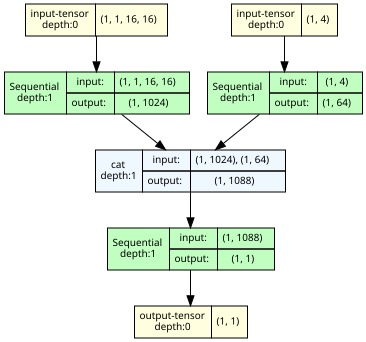

In [7]:
graph2 = draw_graph(
    discriminator,
    input_size=[(1, 1, 16, 16),(1,4)],
    expand_nested=True,
    depth = 1,
    graph_name="Discriminator Architecture",
    mode = 'train',
    show_shapes = True,
    hide_inner_tensors=True,   # Hides intermediate shapes
    roll=True,                  # More compact layer grouping
    save_graph=False,           # Set to True if you want to save
    # node_attr={"color": "lightblue", "style": "filled"},  # Node styling
    # edge_attr={"color": "gray"},                          # Edge styling
    graph_dir= "TB",                         # Layout: TB (top-bottom), LR (left-right)
)
graph2.visual_graph

In [8]:
## Load a previous model
# Replace with the desired filename
load = True

if load:
    # load_path = "models/class_gan_model_0722_2208.pt"
    load_path = "models/class_gan_model_0724_1002.pt"
    
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    stats_dict = checkpoint["stats_dict"]
    
    print(f"Loaded model from {load_path}")

Loaded model from models/class_gan_model_0723_1745.pt


[Epoch 1/100] [D loss: 0.3362] [G loss: 1.3020] [Validity_loss: 0.8396] 
 [Stat_loss: 0.3848] [NNZ_loss: 0.0775]
Sample feature coding: [ 0.         -0.91498977  0.6199335   0.56080997  0.7979314   0.00965048
  0.06894635  0.00377574  0.03137166]


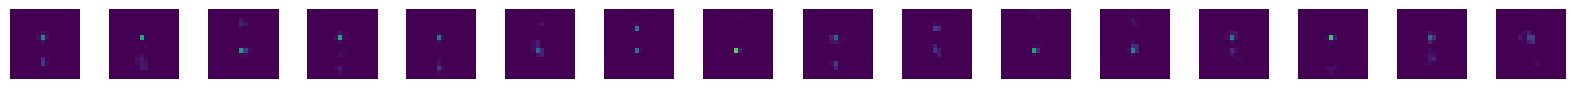

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 2/100] [D loss: 0.3974] [G loss: 1.2899] [Validity_loss: 0.8510] 
 [Stat_loss: 0.3365] [NNZ_loss: 0.1024]
Sample feature coding: [0.         1.6535655  0.98500013 0.33733225 0.7906928  0.01073297
 0.04487018 0.00409058 0.02470961]


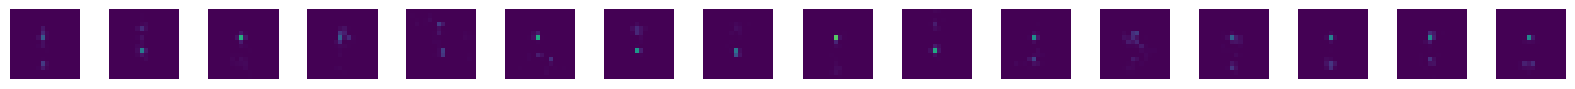

[Epoch 3/100] [D loss: 0.3832] [G loss: 1.1926] [Validity_loss: 0.7657] 
 [Stat_loss: 0.3314] [NNZ_loss: 0.0955]
Sample feature coding: [1.         0.4453196  0.45553732 0.4090462  0.48609212 0.01084901
 0.06070611 0.00407534 0.03645565]


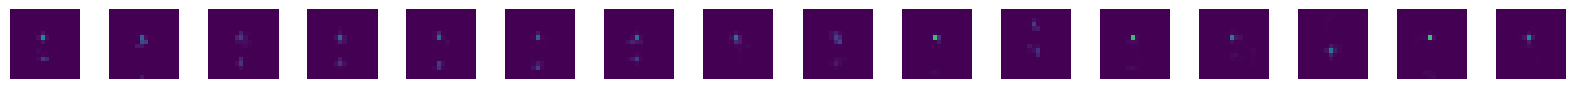

[Epoch 4/100] [D loss: 0.4089] [G loss: 1.3387] [Validity_loss: 0.8387] 
 [Stat_loss: 0.3944] [NNZ_loss: 0.1056]
Sample feature coding: [ 0.         -0.88825727  0.19336234  0.39324772  0.56530106  0.00815769
  0.05348436  0.00378605  0.03342635]


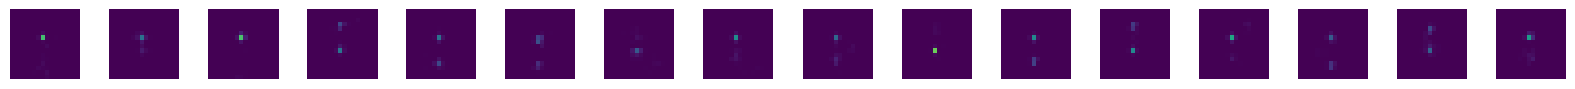

[Epoch 5/100] [D loss: 0.3940] [G loss: 1.3185] [Validity_loss: 0.8778] 
 [Stat_loss: 0.3594] [NNZ_loss: 0.0812]
Sample feature coding: [ 1.         -0.7027281   0.03607876  0.43128687  0.5882012   0.00868747
  0.05764608  0.00376724  0.01839124]


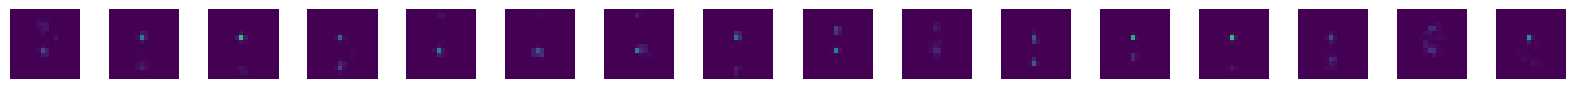

[Epoch 6/100] [D loss: 0.3505] [G loss: 1.3025] [Validity_loss: 0.8222] 
 [Stat_loss: 0.3992] [NNZ_loss: 0.0811]
Sample feature coding: [ 0.         -0.5309074   0.47487247  0.55695176  0.39123392  0.00791463
  0.05625604  0.00392717  0.02083204]


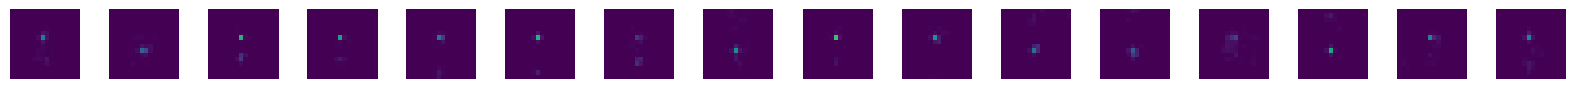

[Epoch 7/100] [D loss: 0.3786] [G loss: 1.2899] [Validity_loss: 0.8662] 
 [Stat_loss: 0.3492] [NNZ_loss: 0.0745]
Sample feature coding: [1.         0.5756463  0.31035316 0.40110624 0.573554   0.01045004
 0.03937746 0.00385076 0.02354602]


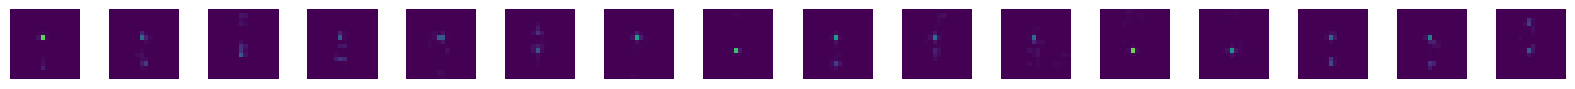

[Epoch 8/100] [D loss: 0.3463] [G loss: 1.4044] [Validity_loss: 0.8531] 
 [Stat_loss: 0.4587] [NNZ_loss: 0.0926]
Sample feature coding: [ 1.         -1.387308    0.03435699  0.4663199   0.5149006   0.0089429
  0.11153778  0.0041389   0.02917382]


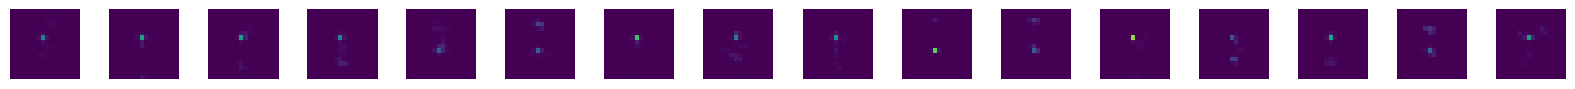

[Epoch 9/100] [D loss: 0.3800] [G loss: 1.2622] [Validity_loss: 0.8900] 
 [Stat_loss: 0.2840] [NNZ_loss: 0.0881]
Sample feature coding: [ 1.         -0.39764744  0.6246961   0.49947134  0.51867634  0.0107354
  0.0650134   0.00420059  0.03024778]


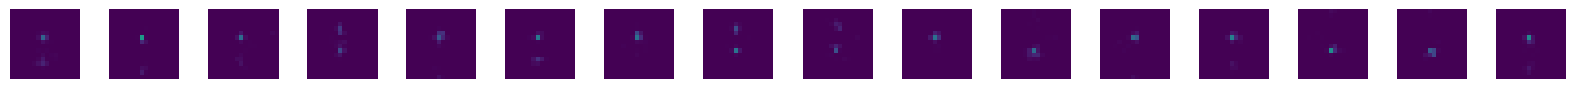

[Epoch 10/100] [D loss: 0.3701] [G loss: 1.3364] [Validity_loss: 0.9170] 
 [Stat_loss: 0.3433] [NNZ_loss: 0.0762]
Sample feature coding: [1.         1.455133   0.05584548 0.3647651  0.42507273 0.00949175
 0.06637534 0.0036845  0.02930323]


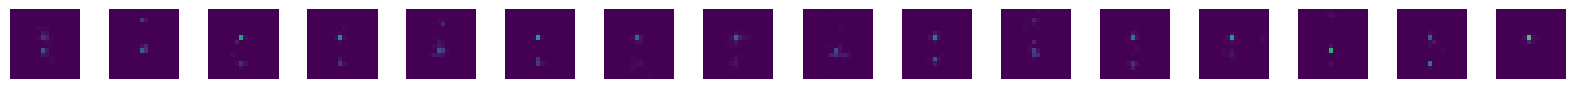

[Epoch 11/100] [D loss: 0.3408] [G loss: 1.2137] [Validity_loss: 0.8275] 
 [Stat_loss: 0.3187] [NNZ_loss: 0.0675]
Sample feature coding: [1.         1.568173   0.19181266 0.46495488 0.45535645 0.01126178
 0.06454408 0.00395972 0.02360586]


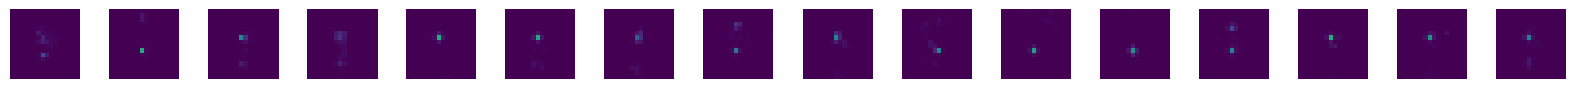

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 12/100] [D loss: 0.4043] [G loss: 1.3230] [Validity_loss: 0.8773] 
 [Stat_loss: 0.3550] [NNZ_loss: 0.0907]
Sample feature coding: [ 1.         -1.3295053   0.22340962  0.3358179   0.52861756  0.00863124
  0.05527006  0.00374049  0.03135629]


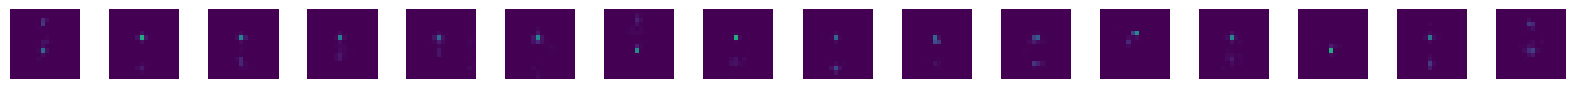

[Epoch 13/100] [D loss: 0.3650] [G loss: 1.2540] [Validity_loss: 0.8406] 
 [Stat_loss: 0.3272] [NNZ_loss: 0.0862]
Sample feature coding: [ 1.         -0.22343414  0.8298485   0.47621432  0.752999    0.00620236
  0.07532335  0.00410308  0.02944974]


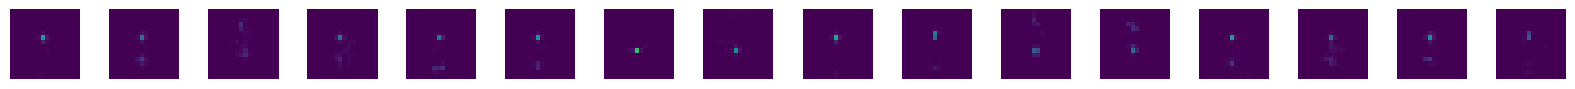

[Epoch 14/100] [D loss: 0.3741] [G loss: 1.2918] [Validity_loss: 0.8209] 
 [Stat_loss: 0.4009] [NNZ_loss: 0.0699]
Sample feature coding: [1.         0.43588    0.5186991  0.6155151  0.55224293 0.00836061
 0.08816626 0.00405607 0.04829268]


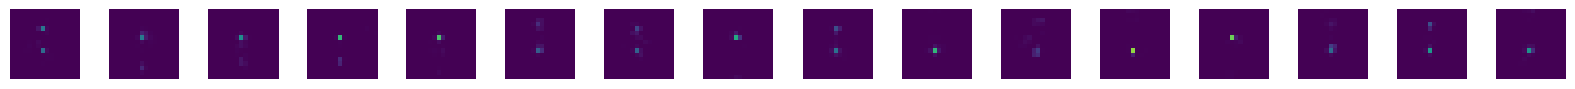

[Epoch 15/100] [D loss: 0.3966] [G loss: 1.4439] [Validity_loss: 0.8685] 
 [Stat_loss: 0.4890] [NNZ_loss: 0.0864]
Sample feature coding: [0.         0.25510594 0.24746336 0.53024125 0.95043045 0.00870854
 0.07190535 0.00354676 0.04092319]


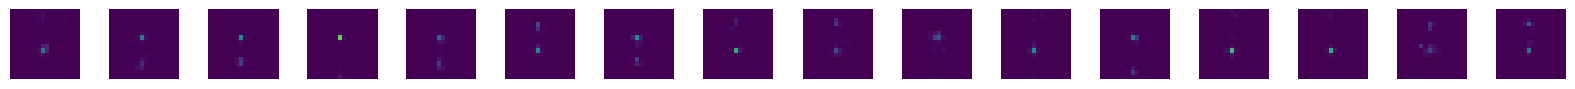

[Epoch 16/100] [D loss: 0.4303] [G loss: 1.2584] [Validity_loss: 0.7907] 
 [Stat_loss: 0.3620] [NNZ_loss: 0.1057]
Sample feature coding: [ 0.         -0.7626342   0.30862138  0.3393334   0.7960094   0.0099302
  0.05062414  0.00414669  0.0318811 ]


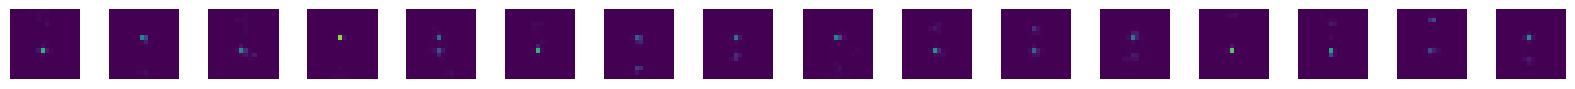

[Epoch 17/100] [D loss: 0.3343] [G loss: 1.1702] [Validity_loss: 0.7888] 
 [Stat_loss: 0.2822] [NNZ_loss: 0.0992]
Sample feature coding: [ 1.         -0.5399022   0.13177449  0.6648123   0.9115222   0.0096958
  0.06027055  0.00382797  0.02180296]


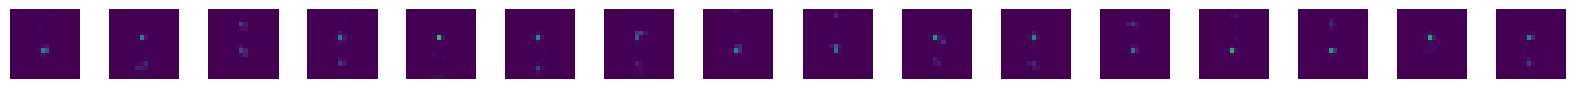

[Epoch 18/100] [D loss: 0.3333] [G loss: 1.2844] [Validity_loss: 0.8642] 
 [Stat_loss: 0.3228] [NNZ_loss: 0.0974]
Sample feature coding: [ 0.         -2.1451154   0.7632289   0.31237018  0.7080743   0.0094307
  0.05702298  0.00356103  0.03863258]


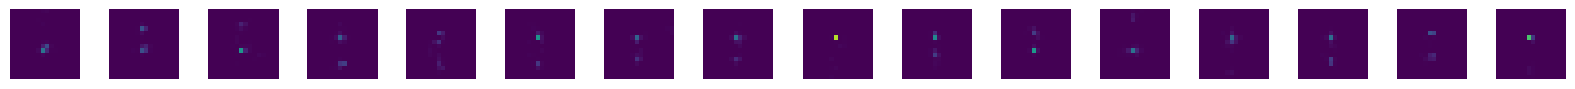

[Epoch 19/100] [D loss: 0.3608] [G loss: 1.3397] [Validity_loss: 0.8302] 
 [Stat_loss: 0.4175] [NNZ_loss: 0.0921]
Sample feature coding: [0.         0.43893707 1.0039451  0.50855577 0.90467435 0.00724533
 0.04929349 0.00393094 0.01703944]


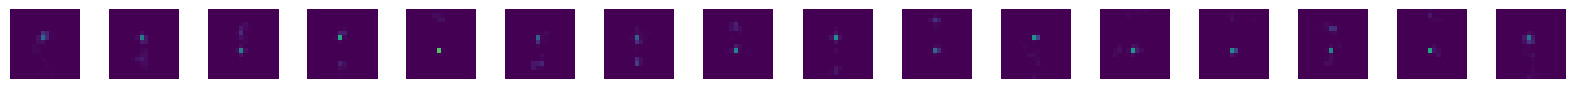

[Epoch 20/100] [D loss: 0.3861] [G loss: 1.3828] [Validity_loss: 0.8817] 
 [Stat_loss: 0.4106] [NNZ_loss: 0.0905]
Sample feature coding: [ 0.         -1.0927061   0.9359905   0.8042394   0.6938542   0.01041462
  0.04778663  0.00357766  0.0291503 ]


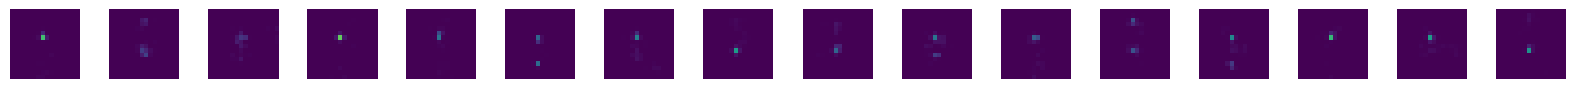

[Epoch 21/100] [D loss: 0.3464] [G loss: 1.4591] [Validity_loss: 0.9470] 
 [Stat_loss: 0.4309] [NNZ_loss: 0.0812]
Sample feature coding: [ 1.         -1.1502535   0.4389391   0.09013742  0.6388534   0.00631651
  0.05764477  0.00399615  0.0173023 ]


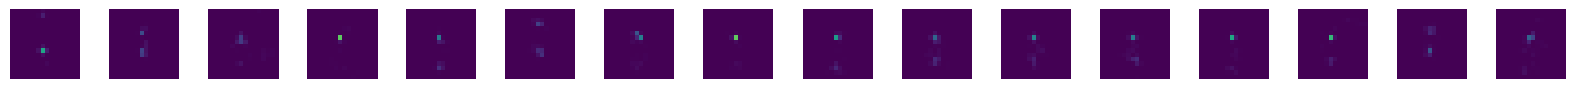

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 22/100] [D loss: 0.3672] [G loss: 1.2556] [Validity_loss: 0.8057] 
 [Stat_loss: 0.3646] [NNZ_loss: 0.0853]
Sample feature coding: [ 0.         -1.7083347   0.24006023  0.43004265  0.60694855  0.00898013
  0.03605041  0.00393247  0.03887799]


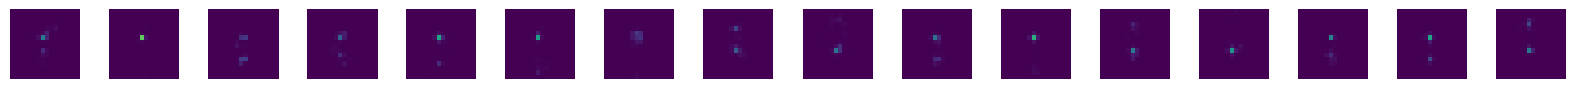

[Epoch 23/100] [D loss: 0.3887] [G loss: 1.3781] [Validity_loss: 0.9402] 
 [Stat_loss: 0.3665] [NNZ_loss: 0.0714]
Sample feature coding: [ 1.         -0.81143934  0.34496725  0.69562423  0.61192775  0.01060745
  0.07828433  0.00365291  0.02929384]


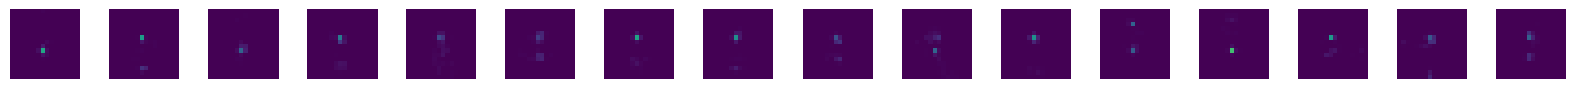

[Epoch 24/100] [D loss: 0.4051] [G loss: 1.3755] [Validity_loss: 0.8862] 
 [Stat_loss: 0.4227] [NNZ_loss: 0.0666]
Sample feature coding: [0.         0.33497864 0.5705607  0.22885208 0.57902837 0.0094871
 0.07053975 0.00398272 0.03742087]


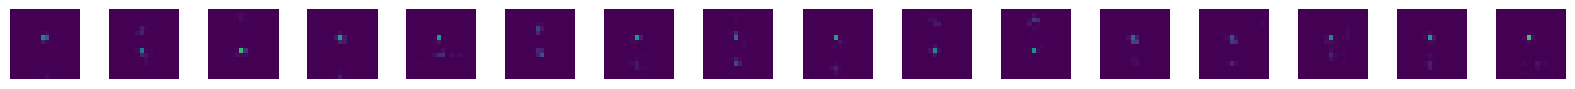

[Epoch 25/100] [D loss: 0.3577] [G loss: 1.2069] [Validity_loss: 0.8336] 
 [Stat_loss: 0.2913] [NNZ_loss: 0.0820]
Sample feature coding: [ 1.         -1.2955136   0.3623459   0.43821818  0.41827184  0.00685149
  0.04168998  0.00398272  0.02781039]


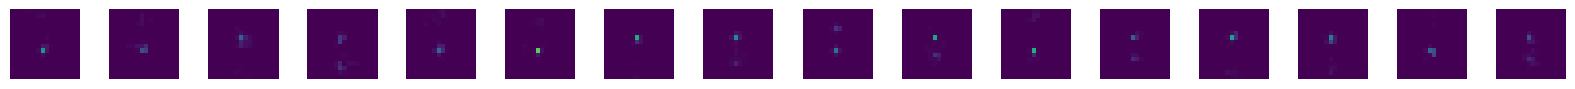

[Epoch 26/100] [D loss: 0.3710] [G loss: 1.3445] [Validity_loss: 0.9400] 
 [Stat_loss: 0.3244] [NNZ_loss: 0.0801]
Sample feature coding: [0.         1.3389387  0.56904554 0.5696822  0.49642548 0.00558939
 0.0428804  0.00378016 0.0432766 ]


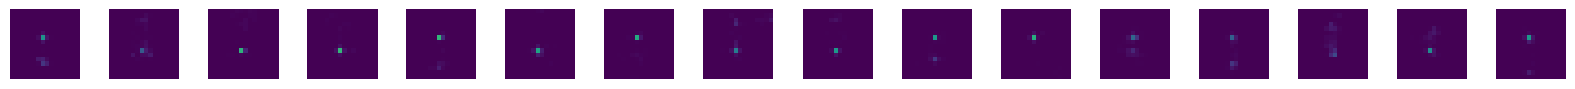

[Epoch 27/100] [D loss: 0.3914] [G loss: 1.3165] [Validity_loss: 0.8694] 
 [Stat_loss: 0.3468] [NNZ_loss: 0.1003]
Sample feature coding: [1.         0.19856732 0.78464323 0.25776702 0.56314236 0.00997491
 0.06170807 0.00411052 0.0197072 ]


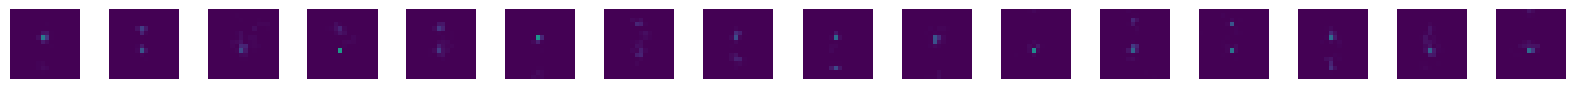

[Epoch 28/100] [D loss: 0.3846] [G loss: 1.4228] [Validity_loss: 0.7943] 
 [Stat_loss: 0.5183] [NNZ_loss: 0.1102]
Sample feature coding: [1.         0.7641724  0.72677314 0.22186323 0.7098383  0.01114067
 0.03761419 0.00406354 0.02546779]


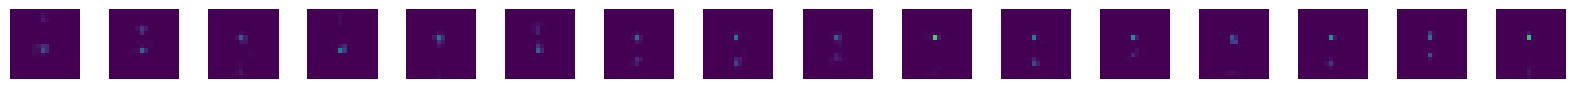

[Epoch 29/100] [D loss: 0.3627] [G loss: 1.2380] [Validity_loss: 0.8361] 
 [Stat_loss: 0.3246] [NNZ_loss: 0.0773]
Sample feature coding: [ 1.         -0.9447308   0.98991805  0.03293288  0.5110743   0.01057239
  0.03046176  0.0036732   0.03827667]


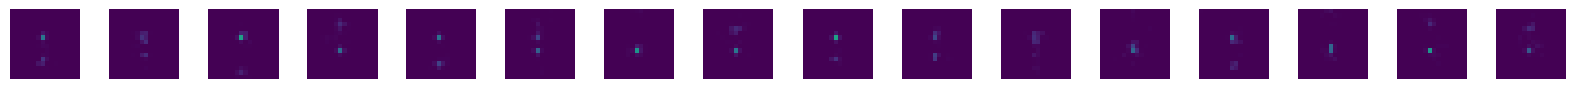

[Epoch 30/100] [D loss: 0.3792] [G loss: 1.3261] [Validity_loss: 0.9475] 
 [Stat_loss: 0.2785] [NNZ_loss: 0.1001]
Sample feature coding: [0.         0.37278533 0.18238811 0.4676116  0.5657325  0.00898182
 0.05865994 0.00364482 0.01747   ]


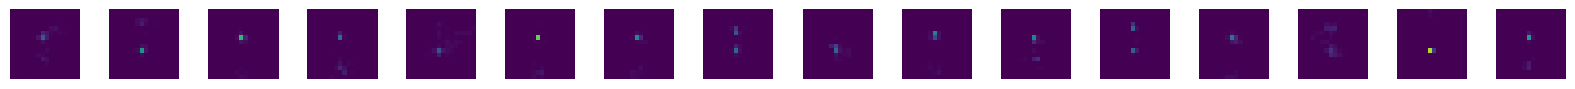

[Epoch 31/100] [D loss: 0.3489] [G loss: 1.3628] [Validity_loss: 0.8555] 
 [Stat_loss: 0.4186] [NNZ_loss: 0.0886]
Sample feature coding: [0.         0.06541616 0.7841536  0.38667184 0.67368317 0.00794412
 0.02614771 0.00348413 0.03349198]


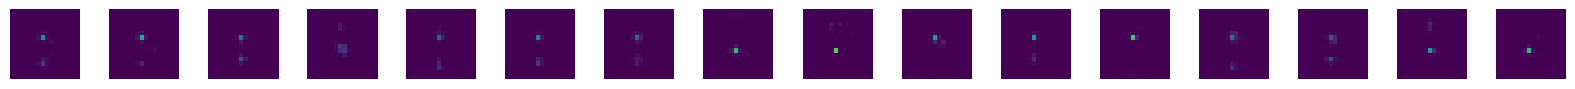

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 32/100] [D loss: 0.3731] [G loss: 1.2770] [Validity_loss: 0.8802] 
 [Stat_loss: 0.3041] [NNZ_loss: 0.0927]
Sample feature coding: [0.         1.7111483  0.14770932 0.394139   0.4406466  0.01009815
 0.07146859 0.00366626 0.01209368]


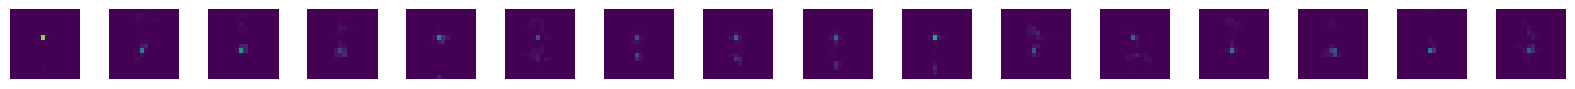

[Epoch 33/100] [D loss: 0.3838] [G loss: 1.4193] [Validity_loss: 0.8778] 
 [Stat_loss: 0.4518] [NNZ_loss: 0.0898]
Sample feature coding: [ 1.         -0.09555572  0.4812108   0.5461637   0.9531537   0.00911356
  0.0398409   0.00398187  0.01442846]


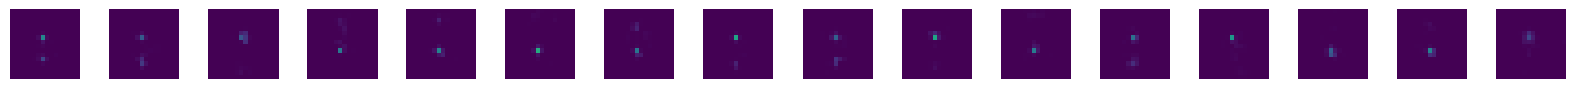

[Epoch 34/100] [D loss: 0.3849] [G loss: 1.3728] [Validity_loss: 0.8945] 
 [Stat_loss: 0.3708] [NNZ_loss: 0.1075]
Sample feature coding: [ 1.         -0.7342339   0.9460523   0.55579185  0.74593115  0.01166597
  0.05632047  0.00376512  0.03416317]


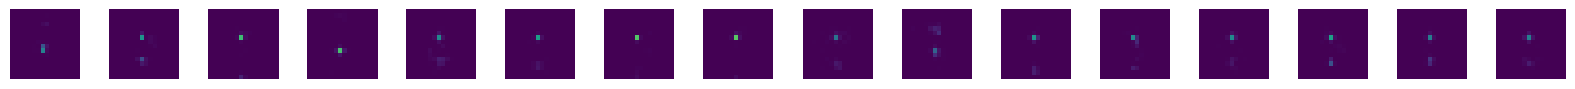

[Epoch 35/100] [D loss: 0.4179] [G loss: 1.3703] [Validity_loss: 0.8883] 
 [Stat_loss: 0.3769] [NNZ_loss: 0.1051]
Sample feature coding: [ 1.         -1.1117824   0.92889035  0.38440904  0.8007075   0.00697226
  0.0549323   0.00397728  0.01989828]


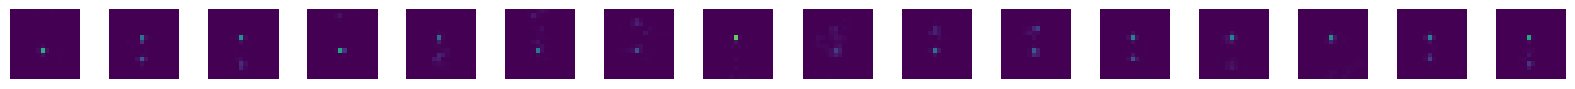

[Epoch 36/100] [D loss: 0.4198] [G loss: 1.4587] [Validity_loss: 0.8968] 
 [Stat_loss: 0.4547] [NNZ_loss: 0.1073]
Sample feature coding: [0.         1.3642776  0.9471717  0.25242844 0.7055546  0.00788378
 0.06091211 0.0036479  0.03206466]


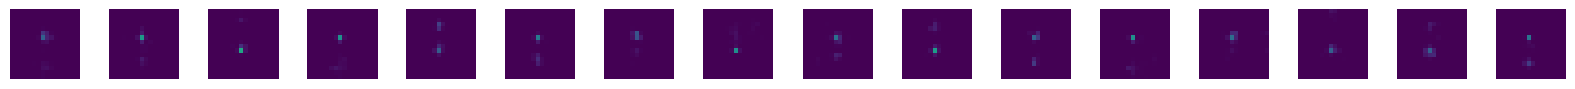

[Epoch 37/100] [D loss: 0.3654] [G loss: 1.4058] [Validity_loss: 0.8650] 
 [Stat_loss: 0.4349] [NNZ_loss: 0.1059]
Sample feature coding: [ 0.         -0.1288934   0.6110655   0.6895502   0.9112628   0.00869654
  0.04326314  0.00386266  0.01916553]


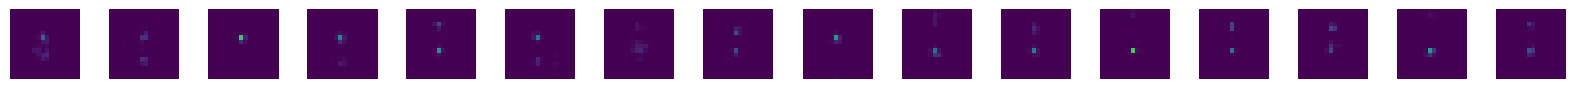

[Epoch 38/100] [D loss: 0.3689] [G loss: 1.2572] [Validity_loss: 0.8752] 
 [Stat_loss: 0.3099] [NNZ_loss: 0.0722]
Sample feature coding: [ 0.         -2.0091112   0.79578143  0.39794368  0.6012042   0.01154938
  0.05995474  0.00373163  0.03685069]


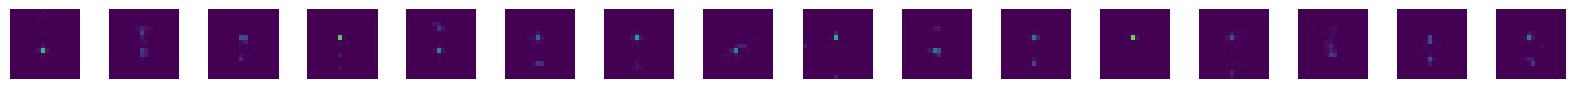

[Epoch 39/100] [D loss: 0.3677] [G loss: 1.3699] [Validity_loss: 0.8588] 
 [Stat_loss: 0.4363] [NNZ_loss: 0.0749]
Sample feature coding: [1.         0.5338425  0.536728   0.1059972  0.31139192 0.01139096
 0.06914434 0.00417222 0.0304081 ]


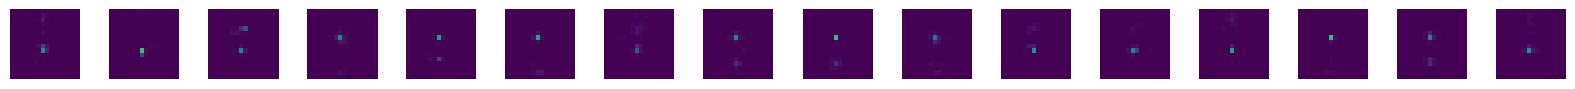

[Epoch 40/100] [D loss: 0.3565] [G loss: 1.3735] [Validity_loss: 0.9444] 
 [Stat_loss: 0.3328] [NNZ_loss: 0.0962]
Sample feature coding: [0.         0.01435087 0.62909037 0.47265193 0.5393988  0.01012033
 0.06188915 0.00388387 0.02899736]


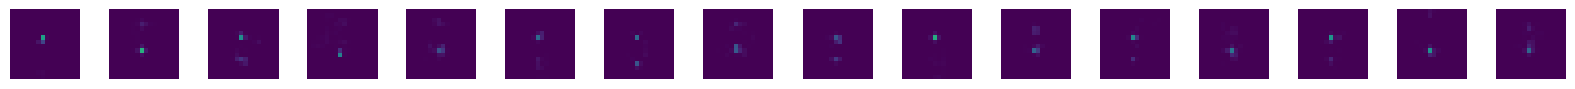

[Epoch 41/100] [D loss: 0.3678] [G loss: 1.2425] [Validity_loss: 0.8198] 
 [Stat_loss: 0.3236] [NNZ_loss: 0.0992]
Sample feature coding: [0.         0.8230051  0.7023674  0.46429387 0.6450298  0.00898833
 0.04719657 0.00356183 0.02423783]


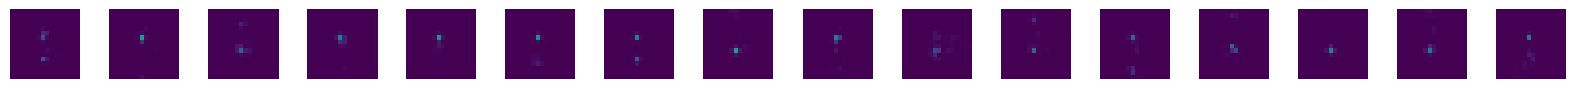

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 42/100] [D loss: 0.3850] [G loss: 1.3872] [Validity_loss: 0.9161] 
 [Stat_loss: 0.3739] [NNZ_loss: 0.0972]
Sample feature coding: [ 0.         -0.23505394  0.42853412  0.36619925  0.35592106  0.00759084
  0.0758174   0.00359619  0.01532632]


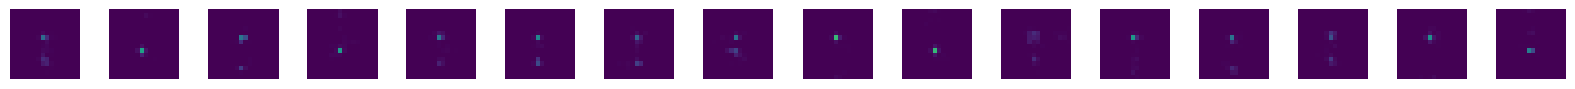

[Epoch 43/100] [D loss: 0.3386] [G loss: 1.3537] [Validity_loss: 0.8568] 
 [Stat_loss: 0.3936] [NNZ_loss: 0.1034]
Sample feature coding: [0.         1.3074877  0.18327503 0.521842   0.5287021  0.00834261
 0.06372023 0.00385604 0.02912778]


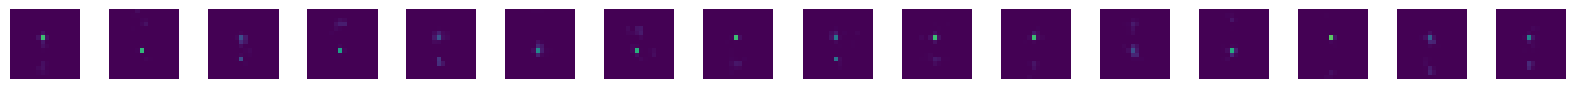

[Epoch 44/100] [D loss: 0.3763] [G loss: 1.2948] [Validity_loss: 0.8794] 
 [Stat_loss: 0.3286] [NNZ_loss: 0.0868]
Sample feature coding: [1.         1.7756549  0.6487801  0.37347877 0.36117858 0.00806823
 0.08926208 0.00371313 0.030833  ]


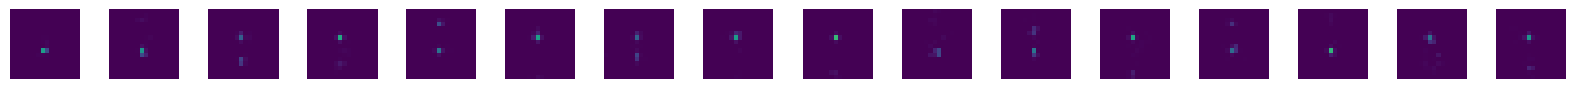

[Epoch 45/100] [D loss: 0.3574] [G loss: 1.3612] [Validity_loss: 0.8829] 
 [Stat_loss: 0.3925] [NNZ_loss: 0.0858]
Sample feature coding: [ 1.         -0.288017    0.7226684   0.14136882  0.53851056  0.00922857
  0.06446344  0.00391583  0.03069979]


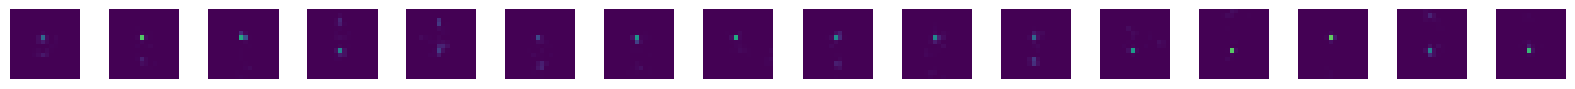

[Epoch 46/100] [D loss: 0.3448] [G loss: 1.3795] [Validity_loss: 0.8520] 
 [Stat_loss: 0.4349] [NNZ_loss: 0.0926]
Sample feature coding: [ 0.         -0.03383937  0.40360966  0.05707601  0.43976578  0.00776917
  0.07399157  0.0036867   0.01651981]


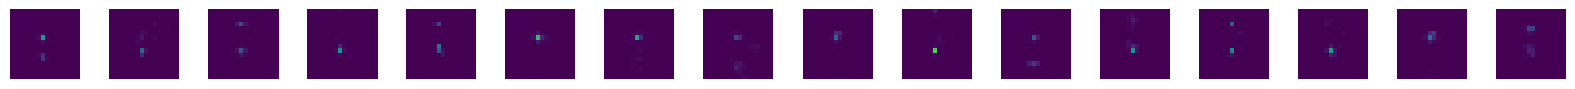

[Epoch 47/100] [D loss: 0.3107] [G loss: 1.2883] [Validity_loss: 0.9226] 
 [Stat_loss: 0.2888] [NNZ_loss: 0.0769]
Sample feature coding: [ 1.         -1.2072005   0.46737805  0.6329304   0.9490472   0.00941856
  0.06152127  0.00386278  0.0311828 ]


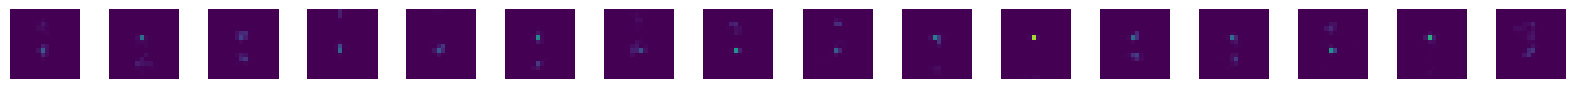

[Epoch 48/100] [D loss: 0.3684] [G loss: 1.3249] [Validity_loss: 0.8241] 
 [Stat_loss: 0.4081] [NNZ_loss: 0.0927]
Sample feature coding: [0.         0.54312503 0.308217   0.06878287 0.6722774  0.0087506
 0.05031545 0.00366875 0.04265009]


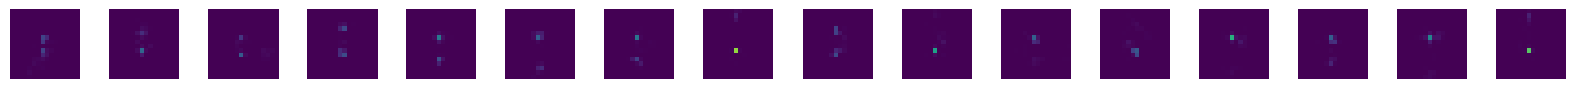

[Epoch 49/100] [D loss: 0.4141] [G loss: 1.2650] [Validity_loss: 0.8194] 
 [Stat_loss: 0.3463] [NNZ_loss: 0.0993]
Sample feature coding: [0.         1.3030858  0.25491172 0.04101319 0.6323281  0.01086807
 0.04683238 0.00393671 0.01936061]


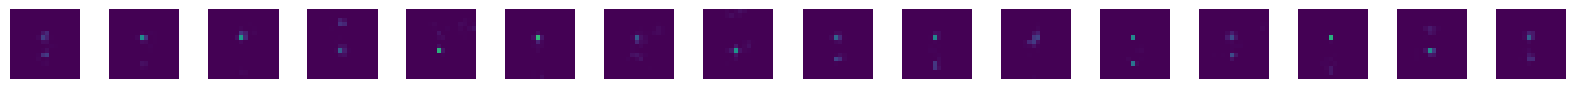

[Epoch 50/100] [D loss: 0.4111] [G loss: 1.3304] [Validity_loss: 0.8539] 
 [Stat_loss: 0.3956] [NNZ_loss: 0.0809]
Sample feature coding: [ 0.         -1.4971635   0.47065866  0.64971477  0.53335035  0.00863199
  0.05741368  0.0037278   0.03036055]


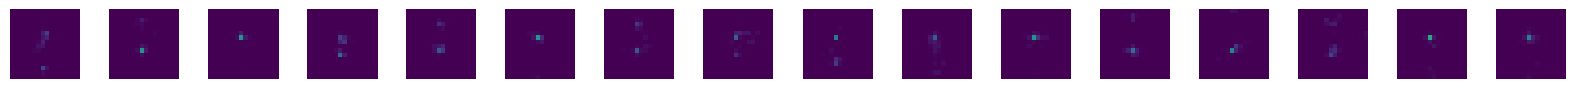

[Epoch 51/100] [D loss: 0.3501] [G loss: 1.2973] [Validity_loss: 0.8226] 
 [Stat_loss: 0.4047] [NNZ_loss: 0.0700]
Sample feature coding: [1.         1.4011235  0.06418812 0.49679604 0.56306297 0.00908596
 0.02926751 0.00381746 0.02711657]


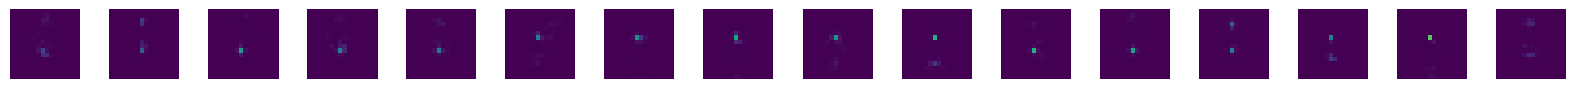

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 52/100] [D loss: 0.3270] [G loss: 1.4075] [Validity_loss: 0.9309] 
 [Stat_loss: 0.3890] [NNZ_loss: 0.0876]
Sample feature coding: [ 0.         -0.8644299   0.37059247  0.13379498  0.6752193   0.0075456
  0.04186197  0.0039548   0.02756822]


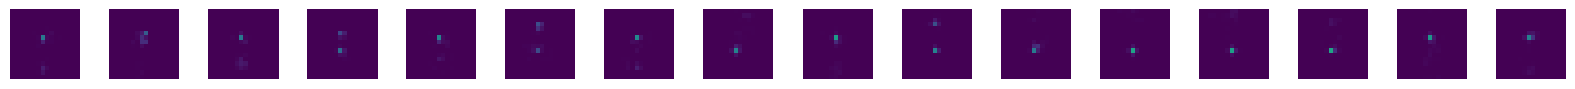

[Epoch 53/100] [D loss: 0.3689] [G loss: 1.3395] [Validity_loss: 0.8877] 
 [Stat_loss: 0.3506] [NNZ_loss: 0.1012]
Sample feature coding: [0.         0.1829059  0.9132237  0.55745333 0.5653517  0.00808372
 0.04292434 0.00395527 0.03588559]


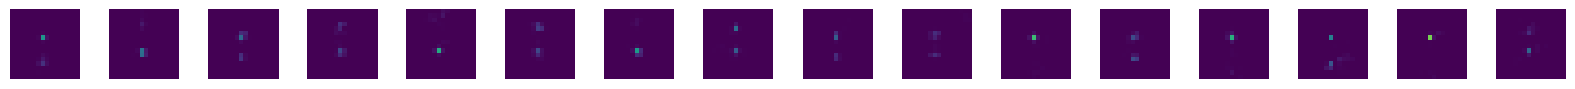

[Epoch 54/100] [D loss: 0.3887] [G loss: 1.1833] [Validity_loss: 0.7295] 
 [Stat_loss: 0.3813] [NNZ_loss: 0.0724]
Sample feature coding: [ 1.         -0.8031505   0.32792145  0.49683022  0.4214203   0.00836132
  0.06314708  0.00405614  0.02793767]


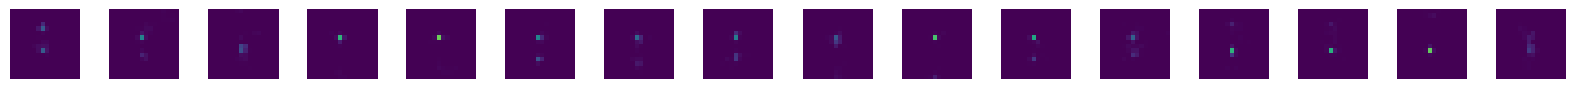

[Epoch 55/100] [D loss: 0.4281] [G loss: 1.4189] [Validity_loss: 0.9322] 
 [Stat_loss: 0.3981] [NNZ_loss: 0.0886]
Sample feature coding: [ 1.         -0.09155174  0.50428575  0.42601508  0.6477169   0.01122171
  0.03649004  0.00327099  0.02218493]


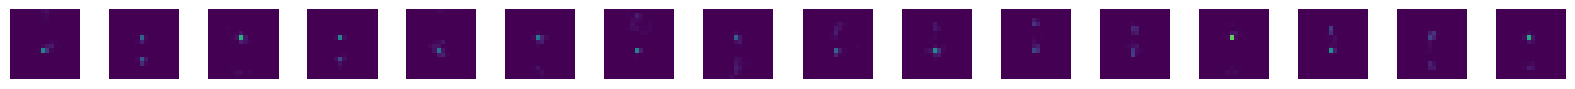

[Epoch 56/100] [D loss: 0.3639] [G loss: 1.2418] [Validity_loss: 0.8502] 
 [Stat_loss: 0.2944] [NNZ_loss: 0.0972]
Sample feature coding: [1.         0.70284724 0.45942235 0.45341396 0.37208143 0.00807686
 0.05769394 0.00396776 0.03668708]


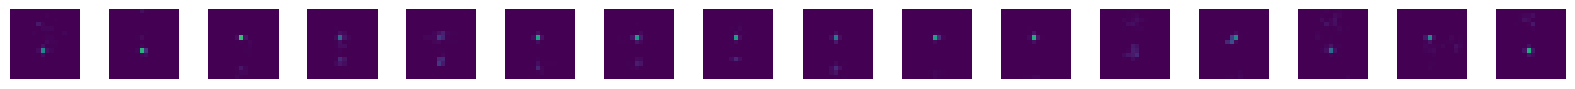

[Epoch 57/100] [D loss: 0.3961] [G loss: 1.4361] [Validity_loss: 0.9152] 
 [Stat_loss: 0.3866] [NNZ_loss: 0.1342]
Sample feature coding: [1.         0.7953105  0.10037313 0.81838065 0.4481857  0.01214688
 0.0652924  0.00402329 0.02267368]


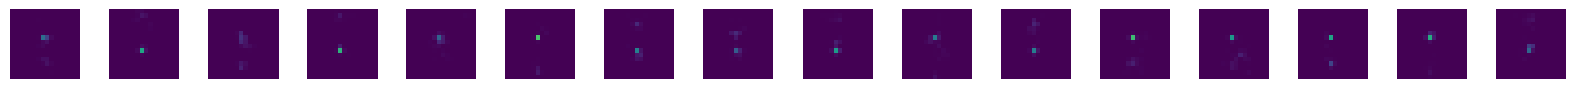

[Epoch 58/100] [D loss: 0.3830] [G loss: 1.3039] [Validity_loss: 0.8799] 
 [Stat_loss: 0.3319] [NNZ_loss: 0.0921]
Sample feature coding: [ 1.         -0.41739497  0.71364033  0.14151543  0.6954011   0.01056803
  0.05515889  0.0040532   0.0148701 ]


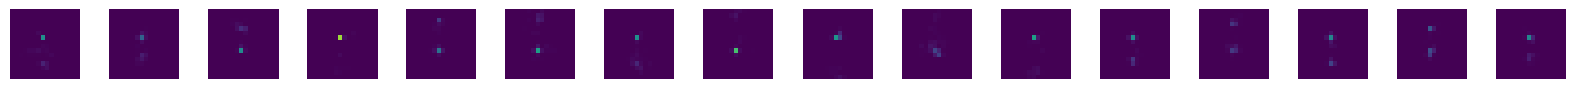

[Epoch 59/100] [D loss: 0.3375] [G loss: 1.4129] [Validity_loss: 0.9152] 
 [Stat_loss: 0.4243] [NNZ_loss: 0.0734]
Sample feature coding: [0.         1.1996806  0.41145188 0.18059577 0.5627267  0.01016178
 0.0521985  0.00399526 0.02847564]


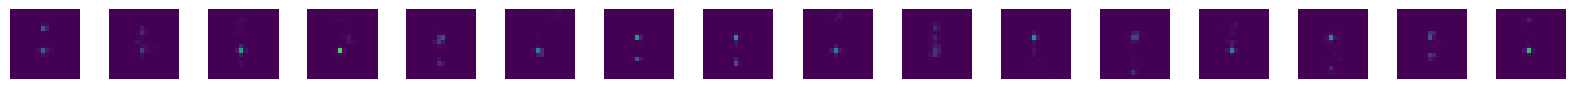

[Epoch 60/100] [D loss: 0.3791] [G loss: 1.3487] [Validity_loss: 0.9265] 
 [Stat_loss: 0.3240] [NNZ_loss: 0.0982]
Sample feature coding: [0.         1.528178   0.246154   0.52250713 0.35517827 0.0102955
 0.06444286 0.00404251 0.02063619]


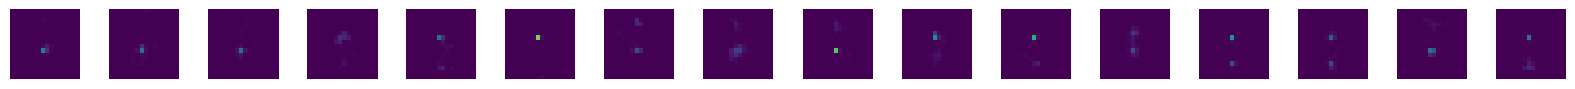

[Epoch 61/100] [D loss: 0.3012] [G loss: 1.2632] [Validity_loss: 0.8232] 
 [Stat_loss: 0.3530] [NNZ_loss: 0.0869]
Sample feature coding: [0.         1.6763593  0.04734842 0.6196989  0.5171776  0.01111673
 0.03407323 0.00394272 0.02516846]


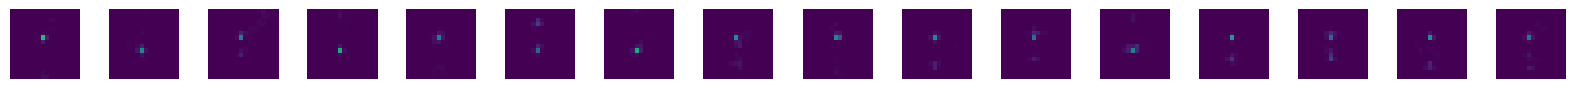

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 62/100] [D loss: 0.3687] [G loss: 1.4009] [Validity_loss: 0.8768] 
 [Stat_loss: 0.4348] [NNZ_loss: 0.0893]
Sample feature coding: [ 1.         -0.07923496  0.19130585  0.11975077  0.42638442  0.00974447
  0.04808805  0.00366189  0.02984866]


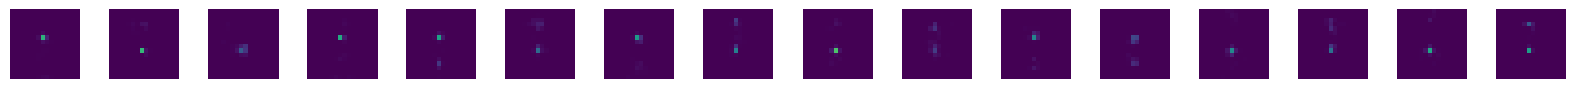

[Epoch 63/100] [D loss: 0.3384] [G loss: 1.4045] [Validity_loss: 0.9195] 
 [Stat_loss: 0.3902] [NNZ_loss: 0.0948]
Sample feature coding: [ 0.         -1.1293439   0.88520205  0.57711804  0.5951935   0.00848424
  0.05339321  0.00360267  0.02829233]


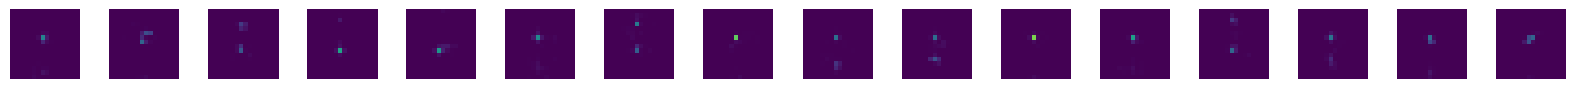

KeyboardInterrupt: 

In [9]:
if True:
    for epoch in range(n_epochs):
        for i, (real_image, real_features, flipped_image, flipped_features) in enumerate(dataloader):
            
            # All real data are normalized in the dataloader
            real_feat = real_features.to(device)
            real_flipped_feat = flipped_features.to(device)
            real_img = real_image.unsqueeze(1).to(device)
            real_flipped_img = flipped_image.unsqueeze(1).to(device)
    
            # print(f"Real: {real_img.shape}")
    
            # Codings will be label, eta, pT, mass that get passed directly to the discriminator
            # All feature values get passed to the generator, then the output image passed to the discriminator
    
            # Discriminator training
            if i % 3 == 0:
                optimizer_D.zero_grad()
                discriminator.train()
                # Generate fake samples
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)

                # Generate the fake image
                fake_img = generator(z_codings)
                # print(f"Fake: {fake_img.shape}")
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1

                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                real_disc_codings = real_feat[:,:num]
                real_flipped_disc_codings = real_flipped_feat[:,:num]
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]

                # Discriminator gets codings + image
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)
    
                preds = (torch.cat([real_pred, real_flipped_pred, fake_pred, fake_flipped_pred], dim=0)).squeeze(1)

                # Labels
                ones = torch.ones(2*len(fake_pred))
                zeros = torch.zeros(2*len(real_pred))
                labels = (torch.cat([ones, zeros], dim=0)).to(device)
    
                # Discriminator loss is just its ability to distinguish
                d_loss = torch.nn.BCELoss()(preds, labels)
    
                d_loss.backward()
                optimizer_D.step()
    
            # Generator Training
            if i % 1 == 0:
                optimizer_G.zero_grad()
                generator.train()
                
                # Generate fake data
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)
    
                # Generate image
                fake_img = generator(z_codings)
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1

                fake_flipped_img = generator(flipped_z_codings)

                ## BCE Discriminator Loss
                # Discriminator gets codings + generated image
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]

                # Get predictions and labels
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)

                target = torch.ones_like(fake_pred)
                bce = nn.BCELoss()
                validity_loss = bce(fake_pred, target) + bce(fake_flipped_pred, target)
    
                ## Stat loss
                # Compute statistics for original and flipped fake images
                fake_stats_orig = compute_fake_statistics(fake_img.to('cpu'), dists.to('cpu'))
                fake_stats_flip = compute_fake_statistics(fake_flipped_img.to('cpu'), dists.to('cpu'))
                
                # Average the statistics
                fake_stats = {
                    'fake_dR_mean': 0.5 * (fake_stats_orig['fake_dR_mean'] + fake_stats_flip['fake_dR_mean']),
                    'fake_dR_std': 0.5 * (fake_stats_orig['fake_dR_std'] + fake_stats_flip['fake_dR_std']),
                    'fake_pixel_mean': 0.5 * (fake_stats_orig['fake_pixel_mean'] + fake_stats_flip['fake_pixel_mean']),
                    'fake_pixel_std': 0.5 * (fake_stats_orig['fake_pixel_std'] + fake_stats_flip['fake_pixel_std']),
                }
                
                # Move to device
                fake_dR_mean = fake_stats['fake_dR_mean'].to(device)
                fake_dR_std = fake_stats['fake_dR_std'].to(device)
                fake_pixel_mean = fake_stats['fake_pixel_mean'].to(device)
                fake_pixel_std = fake_stats['fake_pixel_std'].to(device)
                
                # Get real stats from z_codings (features 5–8)
                real_dR_mean = z_codings[:,5]
                real_dR_std = z_codings[:,6]
                real_pixel_mean = z_codings[:,7]
                real_pixel_std = z_codings[:,8]
                
                real_stats = {
                    'real_dR_mean': real_dR_mean,
                    'real_dR_std': real_dR_std,
                    'real_pixel_mean': real_pixel_mean,
                    'real_pixel_std': real_pixel_std
                }
                
                # stats_dict = track_statistics(fake_stats, real_stats)
                # plot_tracked_statistics(stats_dict)
                
                if n_epochs - epoch <= 10:
                    # Track the last statistics
                    stats_dict = track_statistics(fake_stats, real_stats)
                    plot_tracked_statistics(stats_dict)
                
                # Statistical KL Divergence loss
                kl_total = 0
                kl1 = kde_kl_divergence_torch(real_dR_mean / batch_size, fake_dR_mean) / 0.000001
                # print(f"KL(real_dR_mean, fake_dR_mean) = {kl1.item()}")
                
                kl2 = kde_kl_divergence_torch(real_dR_std / batch_size, fake_dR_std) / 0.003
                # print(f"KL(real_dR_std, fake_dR_std) = {kl2.item()}")
                
                kl3 = kde_kl_divergence_torch(real_pixel_mean / batch_size, fake_pixel_mean) / 0.00000002
                # print(f"KL(real_pixel_mean, fake_pixel_mean) = {kl3.item()}")
                
                kl4 = kde_kl_divergence_torch(real_pixel_std / batch_size, fake_pixel_std) / 0.0003
                # print(f"KL(real_pixel_std, fake_pixel_std) = {kl4.item()}")
                
                kl_total = kl1 + kl2 + kl3 + kl4
    
                stat_loss = kl_total
                
                ## Number non-zero loss
                fake_nnz = soft_count_nonzero(fake_img, threshold=3e-3, sharpness=10000.0)
                real_nnz = soft_count_nonzero(real_img, threshold=3e-3, sharpness=10000.0)
                nnz_loss = torch.nn.MSELoss()(fake_nnz, real_nnz)
    

                # Total generator loss is the average of the discriminator's predictions of the original and flipped data
                # + number of non-zero pixels loss
                # + the difference between input and output dR and pixel statistics
    
                alpha = .2
                beta = .001
                chi = .02
    
                g_loss = (alpha*validity_loss + beta*nnz_loss + chi*stat_loss)

                g_loss.backward()
                optimizer_G.step()
    
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {d_losses[-1]:.4f}] [G loss: {g_losses[-1]:.4f}] [Validity_loss: {alpha*validity_loss:.4f}] \n [Stat_loss: {chi*stat_loss:.4f}] [NNZ_loss: {beta*nnz_loss:.4f}]") 

        plot_generated_samples(generator, dataset, kdes, batch_size=16, latent_dim=256)

        if epoch % 10 == 0:
            # Save model states and tracked data in a temp file during training
            save_path = f"models/class_gan_model_temp.pt"
            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "g_losses": g_losses,
                "d_losses": d_losses,
                "stats_dict": stats_dict
            }, save_path)

            print(f"Model and statistics saved to {save_path}")

In [10]:
## Save Model
# Create output directory if it doesn't exist

save = True

if save:
    os.makedirs("models", exist_ok=True)

    # Timestamp for unique filenames
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Save model states and tracked data in a single file
    save_path = f"models/class_gan_model_{timestamp}.pt"
    torch.save({
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "stats_dict": stats_dict
    }, save_path)
    
    print(f"Model and statistics saved to {save_path}")

Model and statistics saved to models/class_gan_model_0724_1002.pt


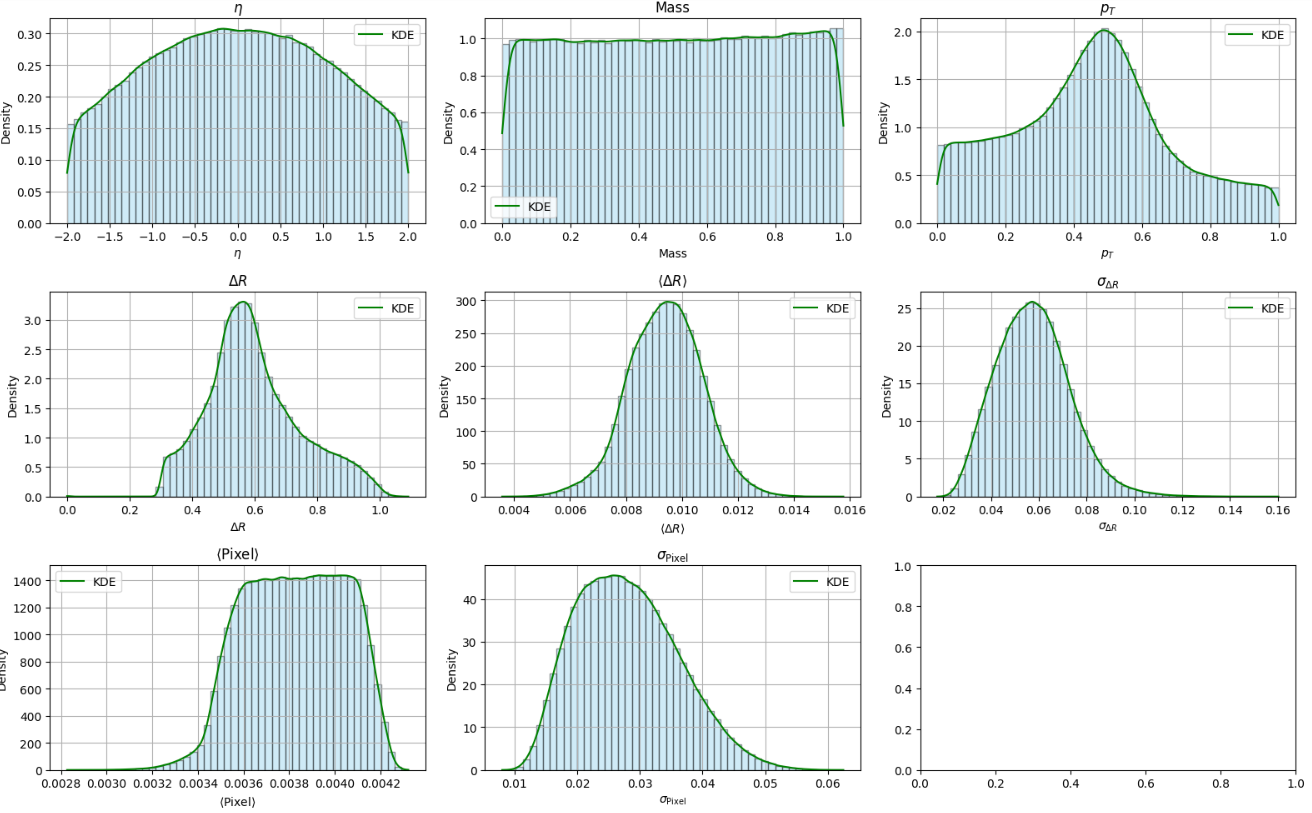

In [ ]:
plot_real_samples(dataset)

Sample feature coding: [ 0.         -0.9651058   0.8519046   0.28832978  0.55093676  0.008513
  0.0566996   0.00394631  0.03280862]


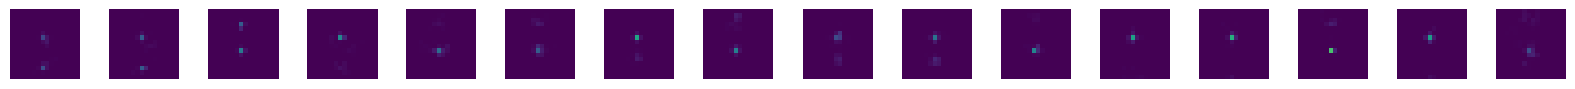

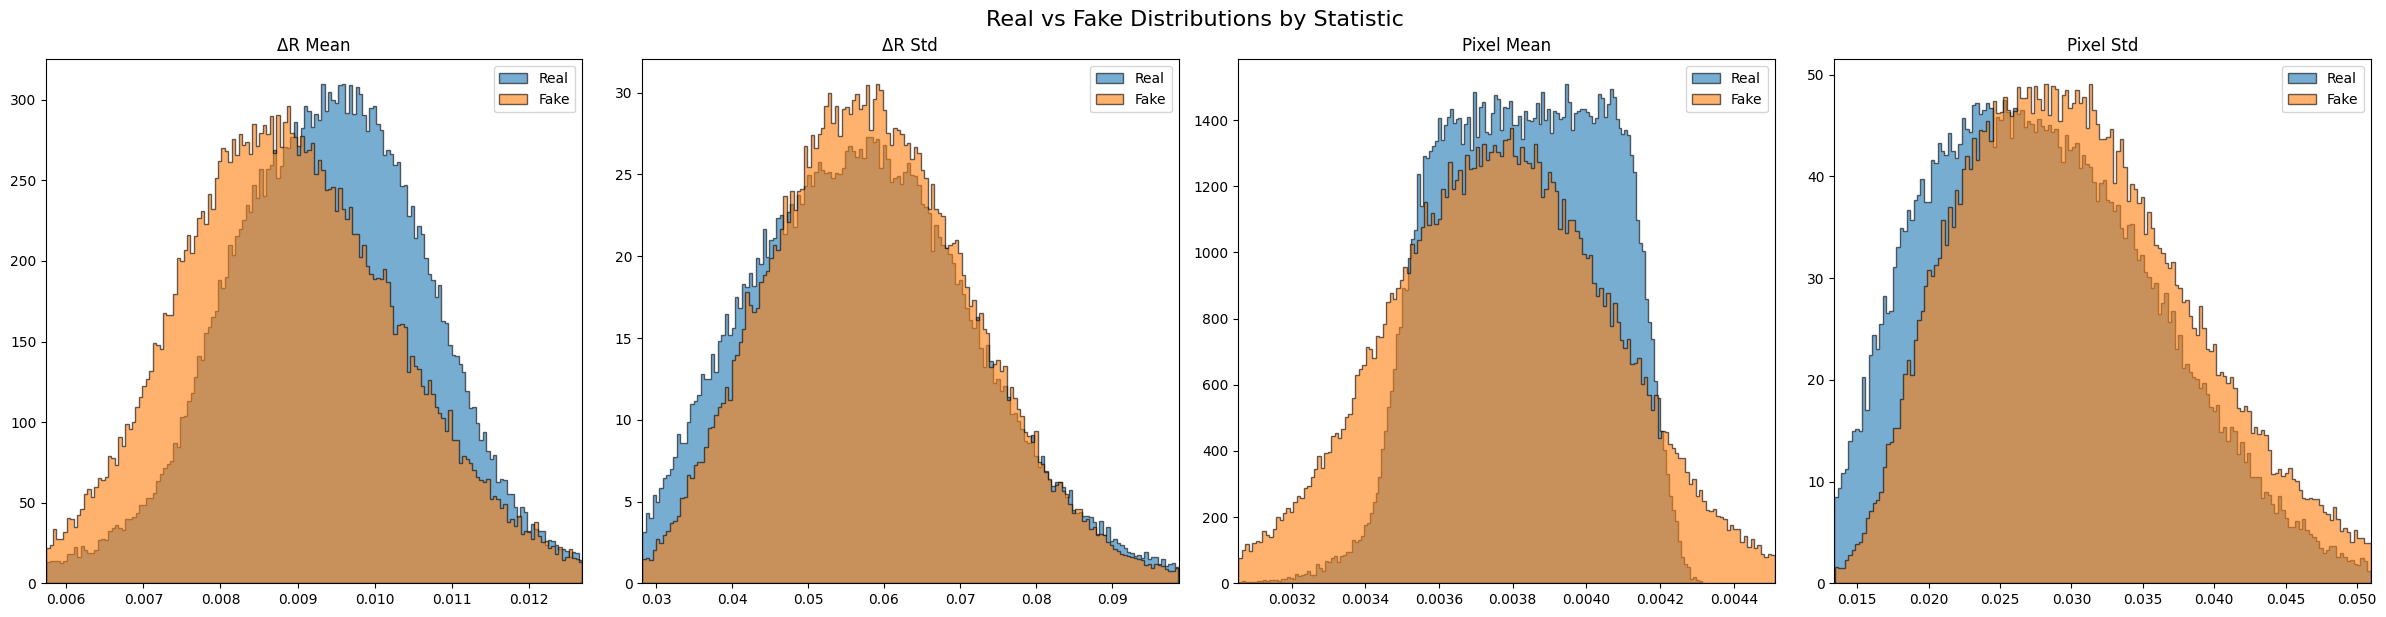

Discriminator output (wrong label): [0.98530585 0.42021486 0.75823534 ... 0.8619952  0.25819743 0.3279576 ]
Discriminator output (correct label): [0.9239248  0.8028665  0.60523695 ... 0.9804701  0.7610243  0.7336782 ]
Real labels: [1. 1. 1. ... 0. 0. 0.]
Swapped labels: [0. 0. 0. ... 0. 0. 0.]
Relative change (%): [  6.64351  -47.660683  25.279093 ... -12.083477 -66.07238  -55.299534]


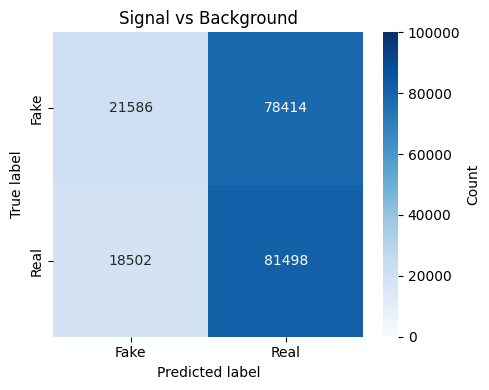

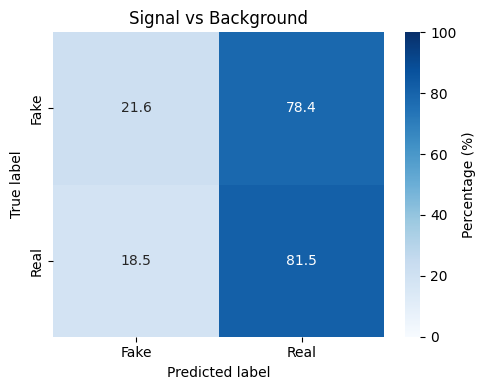

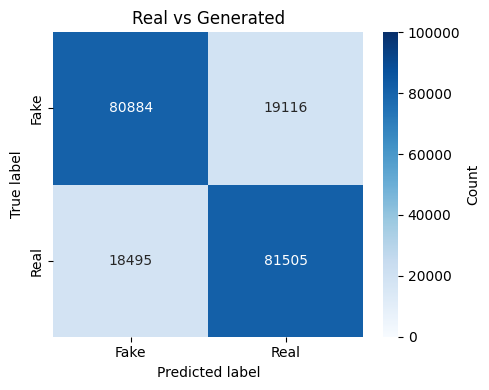

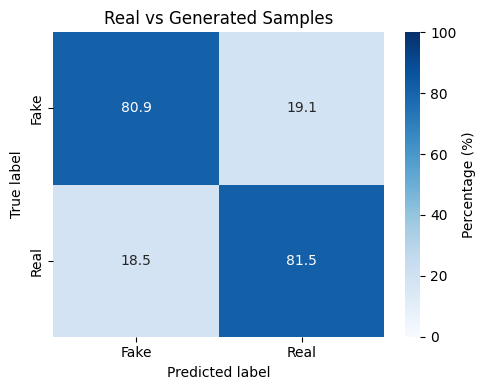

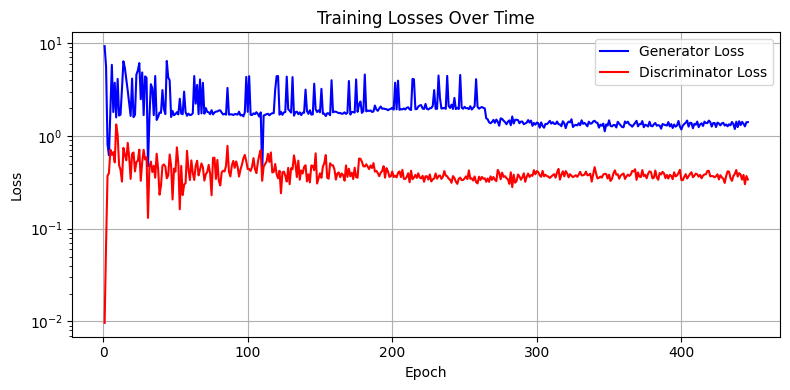

In [11]:
test_generated_samples(generator, discriminator, dataset, kdes, batch_size=100000)

# Optional args:
#     generator,
#     discriminator,
#     dataset,
#     kdes,
#     batch_size=16,
#     latent_dim=256,
#     codings=None,
#     plot_distributions=True,
#     compare_discriminator=True

plot_metrics(g_losses, d_losses)